In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yaml
import csv
from collections import OrderedDict

from pathlib import Path


In [69]:
NOTEBOOK_DIR: Path = Path.cwd()
PROJECT_ROOT: Path = NOTEBOOK_DIR.parent
CONFIG_PATH: Path = PROJECT_ROOT / "config" / "alignment.yml"

with open(CONFIG_PATH, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)


FINAL_ACCESSIONS = PROJECT_ROOT / (config["paths"]["accession_tsv"])


POLYMERASE_BEFORE_CDHIT_TSV = PROJECT_ROOT / (config["paths"]["polymerase_before_cdhit_tsv"])
VP1_BEFORE_CDHIT_TSV = PROJECT_ROOT / (config["paths"]["vp1_before_cdhit_tsv"])

POLYMERASE_ACCESSIONS = PROJECT_ROOT / (config["paths"]["final_final_rdrp_accession_tsv"])
VP1_ACCESSIONS = PROJECT_ROOT / (config["paths"]["final_vp1_accession_tsv"])

MERGED_CSV = PROJECT_ROOT / (config["paths"]["merged_csv"])



In [70]:
accessions_complete = set()
accessions_rdrp_before_cdhit = set()
accessions_vp1_before_cdhit = set()

df_acc = pd.read_csv(FINAL_ACCESSIONS)
df_pa_polymerase_before_cdhit = pd.read_csv(POLYMERASE_BEFORE_CDHIT_TSV)
df_pa_vp1_before_cdhit = pd.read_csv(VP1_BEFORE_CDHIT_TSV)


# adds accessions for sequences in complete
for index, row in df_acc.iterrows():
    accessions_complete.add(row['accession'])

# adds accessions for sequences in partial rdrp
for index, row in df_pa_polymerase_before_cdhit.iterrows():

     accessions_rdrp_before_cdhit.add(row['accession'])

print(len(accessions_rdrp_before_cdhit))

# adds accessions for sequences in partial vp1
for index, row in df_pa_vp1_before_cdhit.iterrows():
    accessions_vp1_before_cdhit.add(row['accession'])


349


## Complete sequences alignment

In [71]:
genotype_dict = {}
p_type_dict = {}

df_complete_spec = pd.read_csv(MERGED_CSV)

could_dict = {}


for acc in accessions_complete:
    subset = df_complete_spec[df_complete_spec["accession"] == acc]

    if subset.empty:
        continue  

    genotype = str(subset.iloc[0]["genotype"])
    p_type = str(subset.iloc[0]["p_type"])

    genotype_dict[genotype] = genotype_dict.get(genotype, 0) + 1
    p_type_dict[p_type] = p_type_dict.get(p_type, 0) + 1
print(f'antal p-typer: {(p_type_dict)}')
print(f'antal genotyper: {(genotype_dict)}')


global_genotype_accession_dict = {}
global_p_type_accession_dict = {}




for index, row in df_complete_spec.iterrows():
    acc = row["accession"]
    if acc in accessions_complete:

        genotype = str(row["genotype"])
        p_type = str(row["p_type"])

        global_genotype_accession_dict.setdefault(genotype, []).append(acc)
        global_p_type_accession_dict.setdefault(p_type, []).append(acc)



        
    
print(f'------\naccessions kopplade till geno-typer:\n{global_genotype_accession_dict}\n')
print(f'------\naccessions kopplade till p-typer:\n{global_p_type_accession_dict}\n')


ptype = []
for lst in global_p_type_accession_dict.values():
    ptype.extend(lst)
print(f'number of p-types: {len(ptype)}')

genotype = []
for lst in global_genotype_accession_dict.values():
    genotype.extend(lst)
print(f'number of genotypes: {len(genotype)}')




antal p-typer: {'GII.P16': 39, 'GII.P4': 31, 'nan': 33, 'GII.P21': 23, 'GII.P2': 5, 'GII.P7': 30, 'GII.P1': 23, 'Could': 14, 'GII.P12': 10, 'GII.P8': 14, 'GII.PNA2': 2, 'GII.P31': 30, 'GII.P17': 20, 'GII.P6': 1, 'GII.P33': 7, 'GII.P25': 1, 'GII.P38': 1, 'GII.PNA7': 1, 'GII.P26': 7, 'GII.P40': 4, 'GII.P23': 1, 'GII.P24': 1}
antal genotyper: {'GII.3': 41, 'GII.4': 70, 'GII.2': 16, 'nan': 33, 'GII.7': 8, 'GII.6': 18, 'GII.1': 29, 'GII.14': 16, 'GII.16': 2, 'GII.8': 14, 'GII.NA2': 2, 'GII.17': 25, 'GII.12': 4, 'GII.26': 7, 'GII.5': 5, 'GII.9': 1, 'GII.23': 1, 'GII.13': 3, 'GII.10': 2, 'GII.24': 1}
------
accessions kopplade till geno-typer:
{'GII.17': ['PV784273.1', 'PV784272.1', 'LC369214.1', 'LC769700.1', 'LC918511.1', 'LC918510.1', 'MH218689.1', 'PQ373128.1', 'PQ373125.1', 'PQ373119.1', 'PV920370.1', 'PQ304632.1', 'MH218591.1', 'MK282256.1', 'MW661253.1', 'OL943802.1', 'PP381824.1', 'PQ373127.1', 'PQ310235.1', 'PQ304633.1', 'PQ304611.1', 'PQ304610.1', 'PV635313.1', 'PV784303.1', 'PZ2347

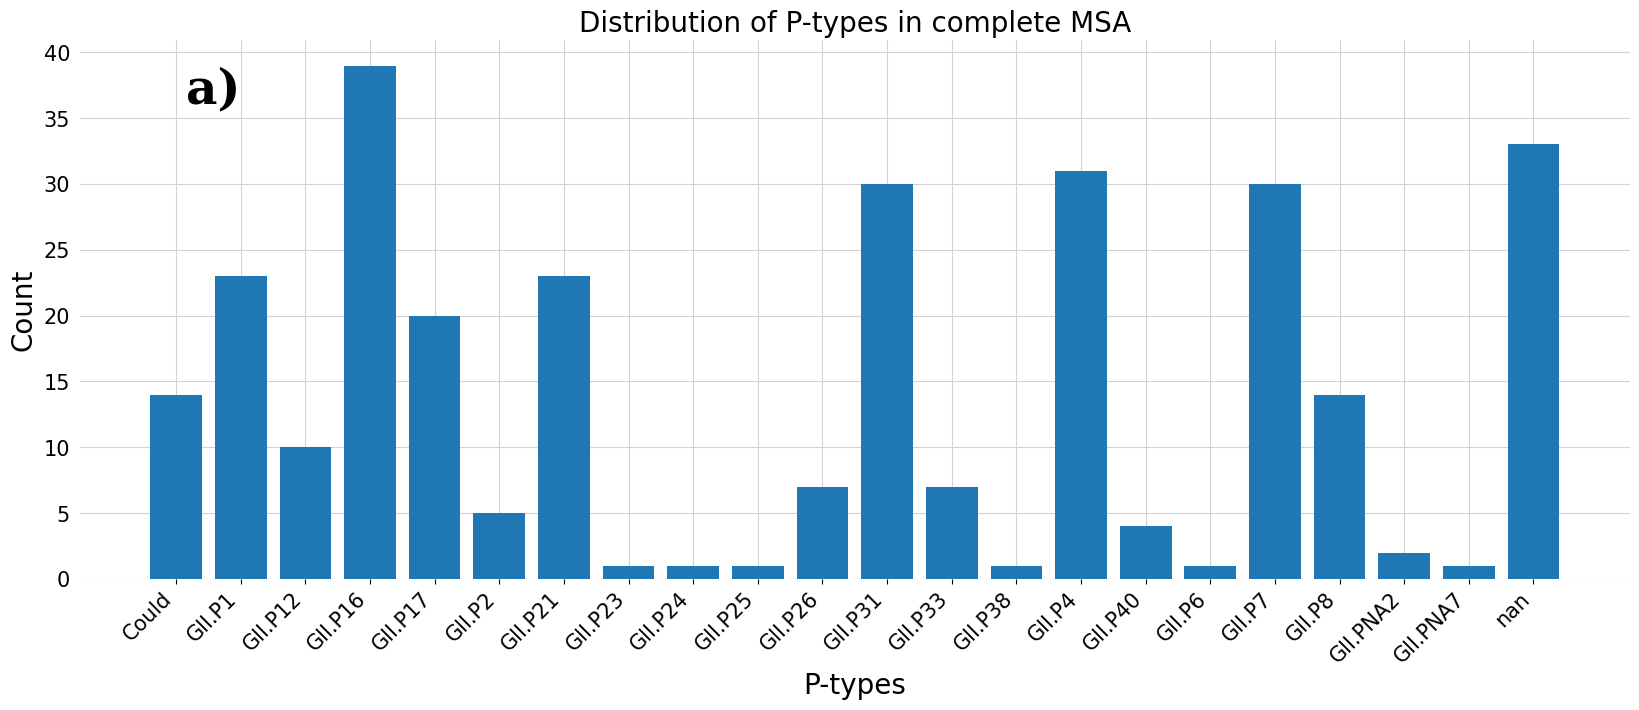

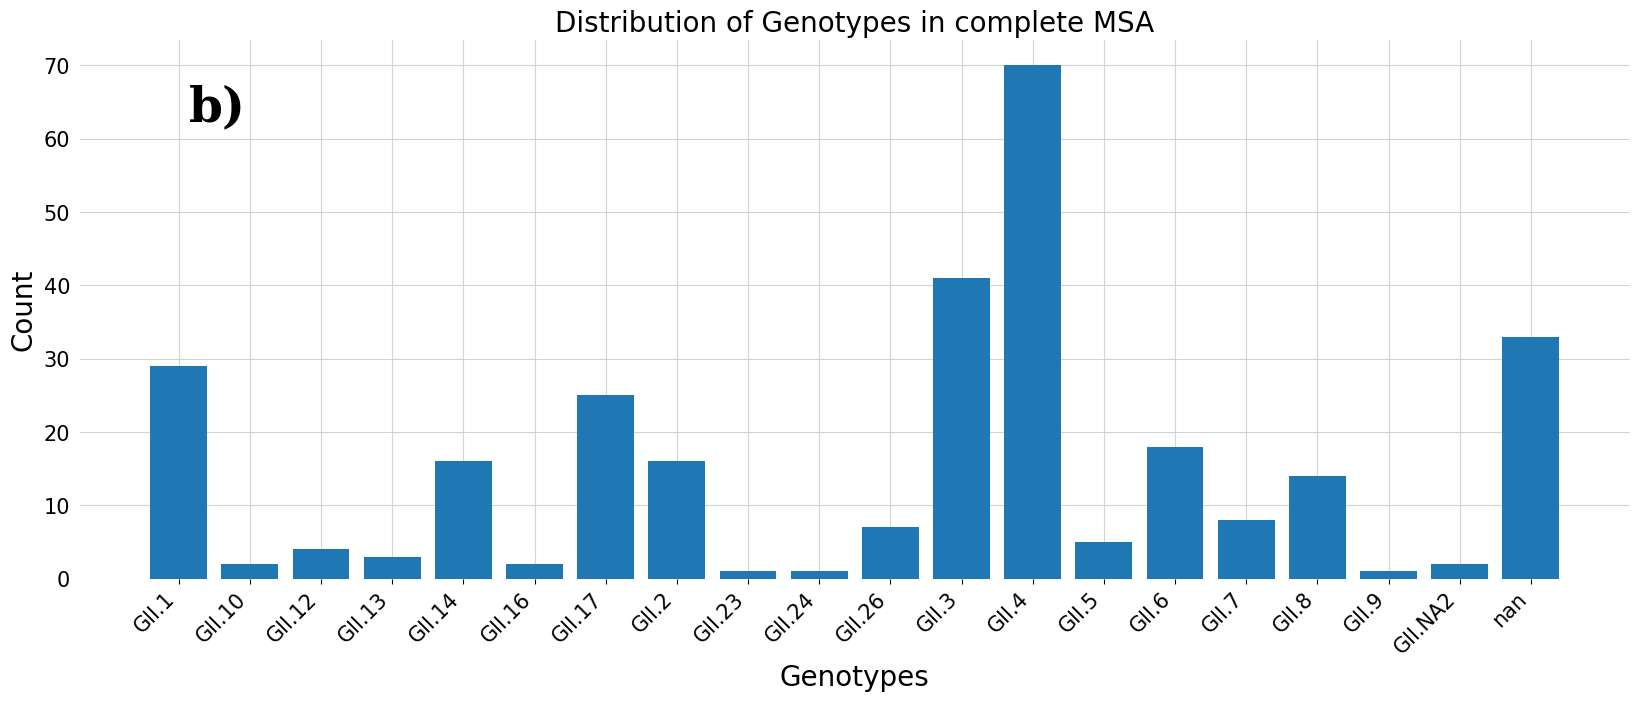

Number of full genome sequences used in global alignemnt: 298
antal p-typer: 298
antal genotyper: 298


In [72]:
p_types = OrderedDict(sorted(p_type_dict.items(), key = lambda item:item[0]))
genotypes = OrderedDict(sorted(genotype_dict.items(), key = lambda item:item[0]))


plt.figure(figsize=(20, 7))
plt.grid(True, color = 'lightgray', zorder=0)
plt.bar(list(p_types.keys()), list(p_types.values()), zorder=3)
plt.xlabel('P-types', fontsize=20)
plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('Count', fontsize=20)
plt.title('Distribution of P-types in complete MSA', fontsize=20)
plt.box(False)
plt.tick_params(left=False, bottom=True)
plt.text(0.15, 39, 'a)',
         fontsize=35,
         fontweight='bold',
         va='top', 
         fontfamily='serif')
plt.show()


plt.figure(figsize=(20, 7))
plt.grid(True, color = 'lightgray', zorder=0)
plt.bar(list(genotypes.keys()), list(genotypes.values()), zorder=3)
plt.xlabel('Genotypes', fontsize=20)
plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('Count', fontsize=20)
plt.title('Distribution of Genotypes in complete MSA', fontsize=20)
plt.box(False)
plt.tick_params(left=False, bottom=True)
plt.text(0.15, 67.5, 'b)',
         fontsize=35,
         fontweight='bold',
         va='top', 
         fontfamily="serif")
plt.show()

print(f'Number of full genome sequences used in global alignemnt: {len(accessions_complete)}')

print(f'antal p-typer: {sum(p_type_dict.values())}')
print(f'antal genotyper: {sum(genotype_dict.values())}')



## RdRp alignment (RdRp regions) before CD-HIT

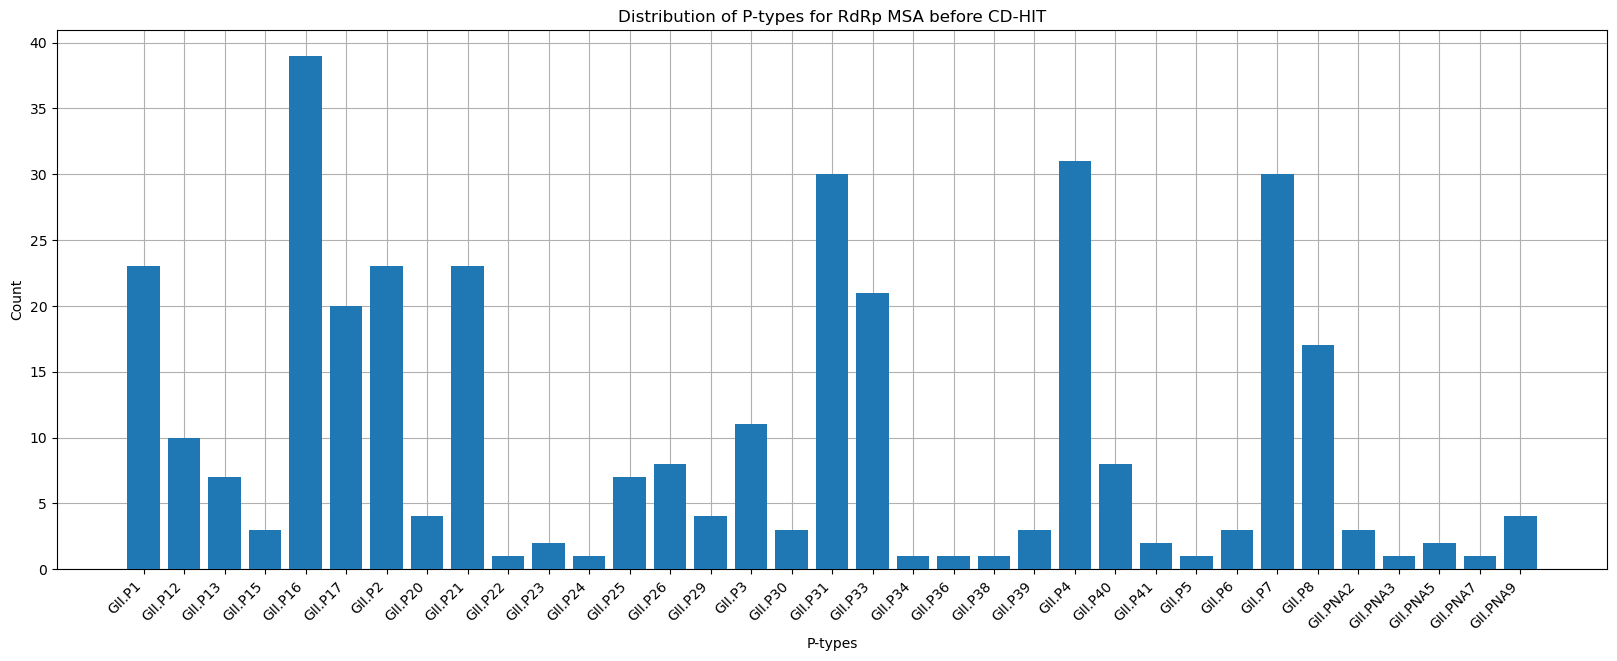

Number of rdrp-sequences in final_rdrp before CD-HIT: 349


In [73]:
polymerase_before_cdhit_dict = {}

df_pa = pd.read_csv(MERGED_CSV)

for index, row in df_pa.iterrows():
    if row['accession'] in accessions_rdrp_before_cdhit:
        
        if row["p_type"] in polymerase_before_cdhit_dict:
            polymerase_before_cdhit_dict[str(row["p_type"])] += 1
        else:
            polymerase_before_cdhit_dict[str(row["p_type"])] = 1


polymerase_before_cdhit_ordered = OrderedDict(sorted(polymerase_before_cdhit_dict.items(), key = lambda item:item[0]))

plt.figure(figsize=(20, 7))
plt.grid(True, zorder=0)
plt.bar(list(polymerase_before_cdhit_ordered.keys()), list(polymerase_before_cdhit_ordered.values()), zorder=3)
plt.xlabel('P-types')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Distribution of P-types for RdRp MSA before CD-HIT')
plt.show()


print(f'Number of rdrp-sequences in final_rdrp before CD-HIT: {sum(polymerase_before_cdhit_ordered.values())}')


## VP1 alignment (VP1 regios) before CD-HIT

386


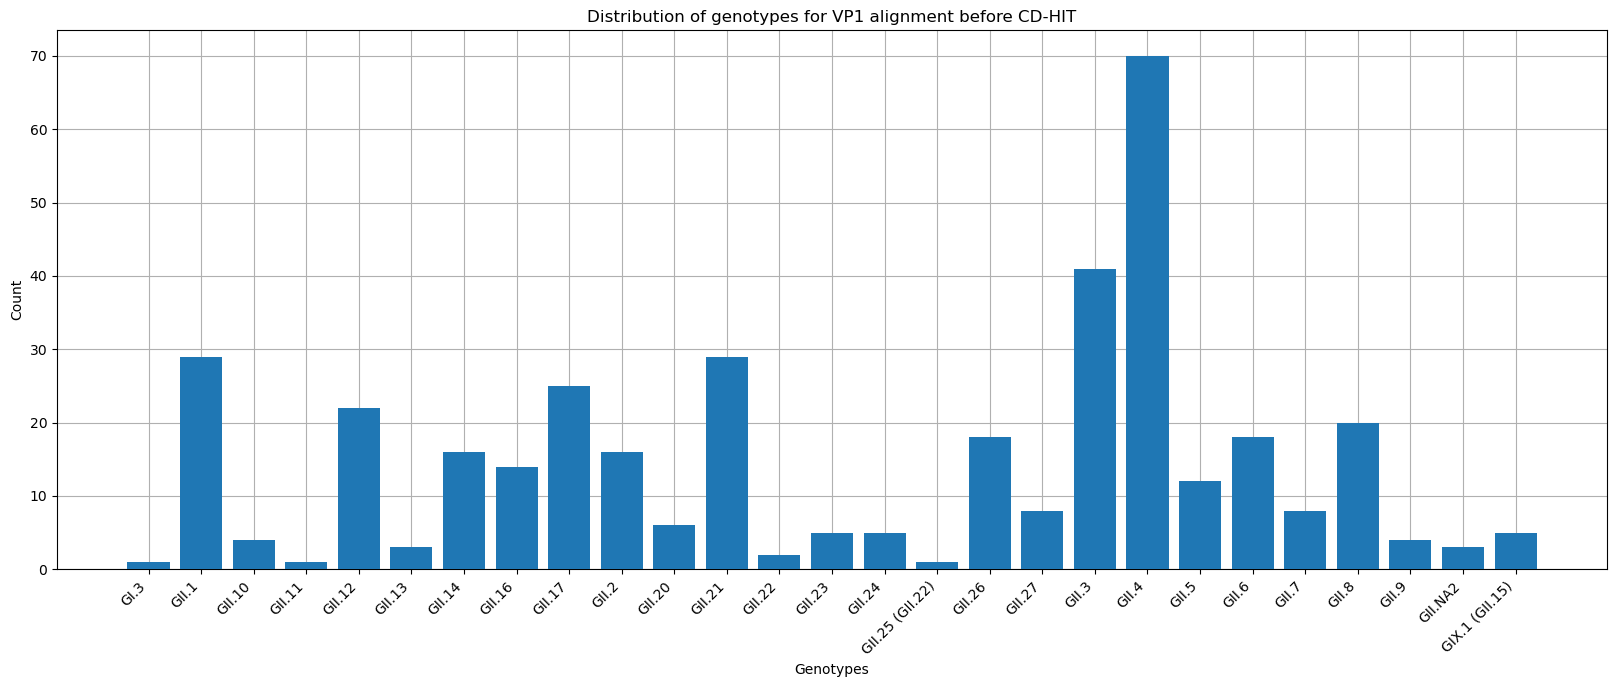

Number of vp1-sequences in final_vp1 before CD-HIT: 386


In [74]:
vp1_before_cdhit_dict = {}

df_pa = pd.read_csv(MERGED_CSV)

for index, row in df_pa.iterrows():
    if row['accession'] in accessions_vp1_before_cdhit:
        
        if row["genotype"] in vp1_before_cdhit_dict:
            vp1_before_cdhit_dict[str(row["genotype"])] += 1
        else:
            vp1_before_cdhit_dict[str(row["genotype"])] = 1


print(sum(vp1_before_cdhit_dict.values()))
vp1_before_cdhit_ordered = OrderedDict(sorted(vp1_before_cdhit_dict.items(), key = lambda item:item[0]))


plt.figure(figsize=(20, 7))
plt.grid(True, zorder=0)
plt.bar(list(vp1_before_cdhit_ordered.keys()), list(vp1_before_cdhit_ordered.values()), zorder=3)
plt.xlabel('Genotypes')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Distribution of genotypes for VP1 alignment before CD-HIT')
plt.show()


print(f'Number of vp1-sequences in final_vp1 before CD-HIT: {sum(vp1_before_cdhit_ordered.values())}')

## RdRp alignment (RdRp-regions) after CD-HIT

In [75]:
accessions_polymerase_after_cdhit = set()

df_pa = pd.read_csv(POLYMERASE_ACCESSIONS)

print(len(df_pa))
for index, row in df_pa.iterrows():
    # print(row)
    # print()
    accessions_polymerase_after_cdhit.add(row['accession'])

print(len(accessions_polymerase_after_cdhit))

###BERÄKNAR ANTAL

polymerase_dict_after_cdhit = {}

df = pd.read_csv(MERGED_CSV)

for index, row in df.iterrows():
    if row['accession'] in accessions_polymerase_after_cdhit:
        
        if row["p_type"] in polymerase_dict_after_cdhit:
            polymerase_dict_after_cdhit[str(row["p_type"])] += 1
        else:
            polymerase_dict_after_cdhit[str(row["p_type"])] = 1


p_type_accession_dict = {}
for index, row in df.iterrows():
    if row['accession'] in accessions_polymerase_after_cdhit:
        
        if row["p_type"] in p_type_accession_dict:
            p_type_accession_dict[str(row["p_type"])].append(row['accession'])
        else:
            p_type_accession_dict[str(row["p_type"])] = [row['accession']]
    
print(f'------\naccessions for the  p-types:\n{p_type_accession_dict}')


300
300
------
accessions for the  p-types:
{'GII.P17': ['PV784273.1', 'PV784272.1', 'LC369214.1', 'LC918511.1', 'LC918510.1', 'MH218689.1', 'PQ373128.1', 'PQ373125.1', 'PQ373119.1', 'MK282256.1', 'MW661253.1', 'PP381824.1', 'PQ373127.1', 'PQ310235.1', 'PQ304633.1', 'PQ304611.1', 'PQ304610.1', 'PV635313.1', 'PV784303.1', 'PZ234772.1'], 'GII.P16': ['PX285874.1', 'GU292831.4', 'HM596590.4', 'KT779557.1', 'LC769707.1', 'MG572182.1', 'PV843276.1', 'OP609646.1', 'PQ195894.1', 'PQ273191.1', 'PQ195926.1', 'MH218591.1', 'MN447470.1', 'OP686903.1', 'PP549876.1', 'PQ215525.1', 'PZ240487.1'], 'GII.P31': ['KY496327.1', 'LC769681.1', 'MH218657.1', 'MH218620.1', 'MN307997.1', 'MN308019.1', 'MG214988.1', 'PV275048.1', 'PQ195913.1', 'PQ207947.1', 'PQ304632.1', 'MK789435.1', 'MN400355.2', 'MT028542.1', 'OL943802.1', 'PP658552.1', 'PQ218468.1', 'PV275040.1'], 'GII.P4': ['KY905331.1', 'MG548737.1', 'MG049692.1', 'MH218714.1', 'MH218669.1', 'MH218652.1', 'MW581004.1', 'MZ291634.1', 'MW581008.1', 'MG002632

Number of rdrp-sequences in final_rdrp after CD-HIT: 300


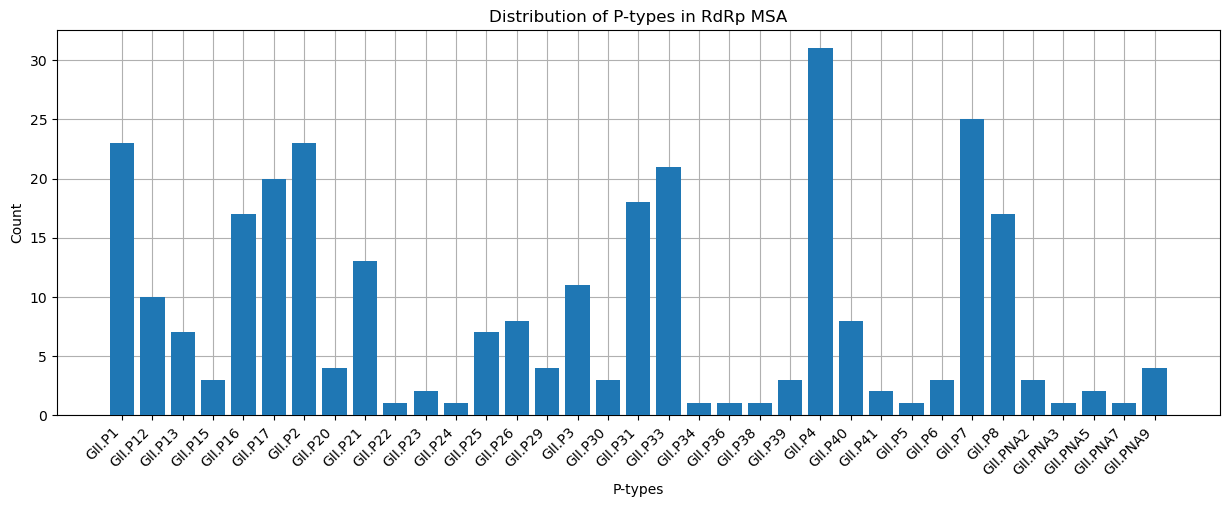

OrderedDict({'GII.P1': 23, 'GII.P12': 10, 'GII.P13': 7, 'GII.P15': 3, 'GII.P16': 17, 'GII.P17': 20, 'GII.P2': 23, 'GII.P20': 4, 'GII.P21': 13, 'GII.P22': 1, 'GII.P23': 2, 'GII.P24': 1, 'GII.P25': 7, 'GII.P26': 8, 'GII.P29': 4, 'GII.P3': 11, 'GII.P30': 3, 'GII.P31': 18, 'GII.P33': 21, 'GII.P34': 1, 'GII.P36': 1, 'GII.P38': 1, 'GII.P39': 3, 'GII.P4': 31, 'GII.P40': 8, 'GII.P41': 2, 'GII.P5': 1, 'GII.P6': 3, 'GII.P7': 25, 'GII.P8': 17, 'GII.PNA2': 3, 'GII.PNA3': 1, 'GII.PNA5': 2, 'GII.PNA7': 1, 'GII.PNA9': 4})


In [76]:
print(f'Number of rdrp-sequences in final_rdrp after CD-HIT: {sum(polymerase_dict_after_cdhit.values())}')

polymerase_after_cdhit_ordered = OrderedDict(sorted(polymerase_dict_after_cdhit.items(), key = lambda item:item[0]))

plt.figure(figsize=(15, 5))
plt.grid(True, zorder=0)
plt.bar(list(polymerase_after_cdhit_ordered.keys()), list(polymerase_after_cdhit_ordered.values()), zorder=3)
plt.xlabel('P-types')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Distribution of P-types in RdRp MSA')
plt.show()

print(polymerase_after_cdhit_ordered)

## VP1 alignment (VP1 regions) after CD-HIT

In [77]:
accessions_vp1_after_cdhit = set()

df_pa_vp1 = pd.read_csv(VP1_ACCESSIONS)

print(len(df_pa_vp1))
for index, row in df_pa_vp1.iterrows():
    accessions_vp1_after_cdhit.add(row['accession'])

print(len(accessions_vp1_after_cdhit))


vp1_dict = {}

df = pd.read_csv(MERGED_CSV)

for index, row in df.iterrows():
    if row['accession'] in accessions_vp1_after_cdhit:
        
        if row["genotype"] in vp1_dict:
            vp1_dict[str(row["genotype"])] += 1
        else:
            vp1_dict[str(row["genotype"])] = 1

# print(vp1_dict["GIX.1 (GII.15)"])


genotype_accession_dict = {}
for index, row in df.iterrows():
    if row['accession'] in accessions_vp1_after_cdhit:
        
        if row["genotype"] in genotype_accession_dict:
            genotype_accession_dict[str(row["genotype"])].append(row['accession'])
        else:
            genotype_accession_dict[str(row["genotype"])] = [row['accession']]
    
print(f'------\naccessions for the genotypes:\n{genotype_accession_dict}')

    

310
310
------
accessions for the genotypes:
{'GII.17': ['PV784273.1', 'PV784272.1', 'LC369214.1', 'LC769700.1', 'LC918511.1', 'LC918510.1', 'MH218689.1', 'PQ373128.1', 'PQ373125.1', 'PQ373119.1', 'PV920370.1', 'PQ304632.1', 'MH218591.1', 'MK282256.1', 'MW661253.1', 'OL943802.1', 'PP381824.1', 'PQ373127.1', 'PQ310235.1', 'PQ304633.1', 'PQ304611.1', 'PQ304610.1', 'PV635313.1', 'PV784303.1', 'PZ234772.1'], 'GII.2': ['PX285872.1', 'MH218657.1', 'MH218655.1', 'PV843276.1', 'MK614125.1', 'MK773587.1', 'MK752941.1', 'MK729086.1', 'MK753012.1', 'OR065073.1', 'MH979229.1', 'MK753015.1', 'MT724793.1', 'MW661246.1', 'OL898507.1', 'OK376253.1'], 'GII.16': ['GU292831.4', 'LC769702.1', 'MN447470.1', 'PX458533.1', 'PV394759.1', 'PV394760.1', 'PV394761.1', 'PV394762.1', 'PV394763.1', 'PV394766.1', 'PV394767.1', 'PV394768.1', 'MZ769132.1', 'MW305699.1'], 'GII.5': ['HM596590.4', 'MZ265142.1', 'MW009072.1', 'MW009068.1', 'PQ641315.1', 'MZ268406.1', 'MW009069.1', 'MW305533.1', 'MW305537.1', 'MW305658.1',

Number of vp1-sequences in final_vp1 after CD-HIT: 310


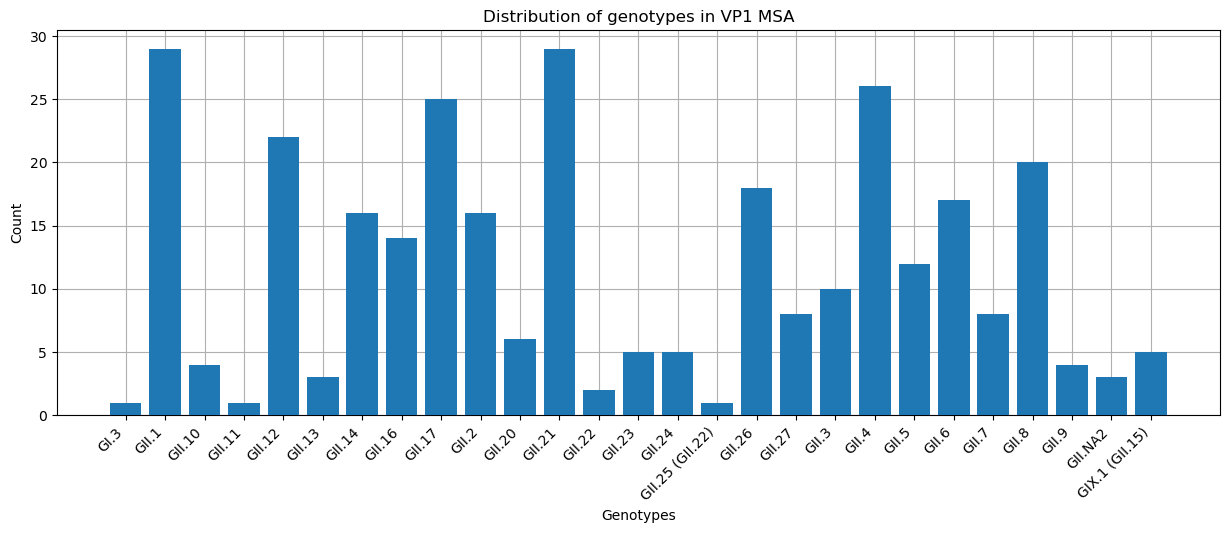

OrderedDict({'GI.3': 1, 'GII.1': 29, 'GII.10': 4, 'GII.11': 1, 'GII.12': 22, 'GII.13': 3, 'GII.14': 16, 'GII.16': 14, 'GII.17': 25, 'GII.2': 16, 'GII.20': 6, 'GII.21': 29, 'GII.22': 2, 'GII.23': 5, 'GII.24': 5, 'GII.25 (GII.22)': 1, 'GII.26': 18, 'GII.27': 8, 'GII.3': 10, 'GII.4': 26, 'GII.5': 12, 'GII.6': 17, 'GII.7': 8, 'GII.8': 20, 'GII.9': 4, 'GII.NA2': 3, 'GIX.1 (GII.15)': 5})


In [78]:
vp1_after_cdhit_ordered = OrderedDict(sorted(vp1_dict.items(), key = lambda item:item[0]))

print(f'Number of vp1-sequences in final_vp1 after CD-HIT: {sum(vp1_after_cdhit_ordered.values())}')

plt.figure(figsize=(15, 5))
plt.grid(True, zorder=0)
plt.bar(list(vp1_after_cdhit_ordered.keys()), list(vp1_after_cdhit_ordered.values()), zorder=3)
plt.xlabel('Genotypes')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Distribution of genotypes in VP1 MSA')
plt.show()

print(vp1_after_cdhit_ordered)

__________________________________---